### Multiclass Classification with Logistic Regression -  Example and Exercise

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
)

In [ ]:
from sklearn.datasets import load_iris

iris = load_iris()

In [4]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [5]:
iris_df = pd.DataFrame(
    data=iris.data, columns=iris.feature_names)
iris_df['species'] = iris.target

iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [6]:
# * To display specific rows and all columns of the DataFrame, you can use the `iloc` method. For example, to display the rows at index 1, 50, and 100, you can use the following code:
iris_df.iloc[[1,50,100], :]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
1,4.9,3.0,1.4,0.2,0
50,7.0,3.2,4.7,1.4,1
100,6.3,3.3,6.0,2.5,2


In [7]:
iris_df['species_name'] = iris_df['species'].apply(lambda x: iris.target_names[x])

iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


In [8]:
iris_df.iloc[[1,50,100], :]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
1,4.9,3.0,1.4,0.2,0,setosa
50,7.0,3.2,4.7,1.4,1,versicolor
100,6.3,3.3,6.0,2.5,2,virginica


<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

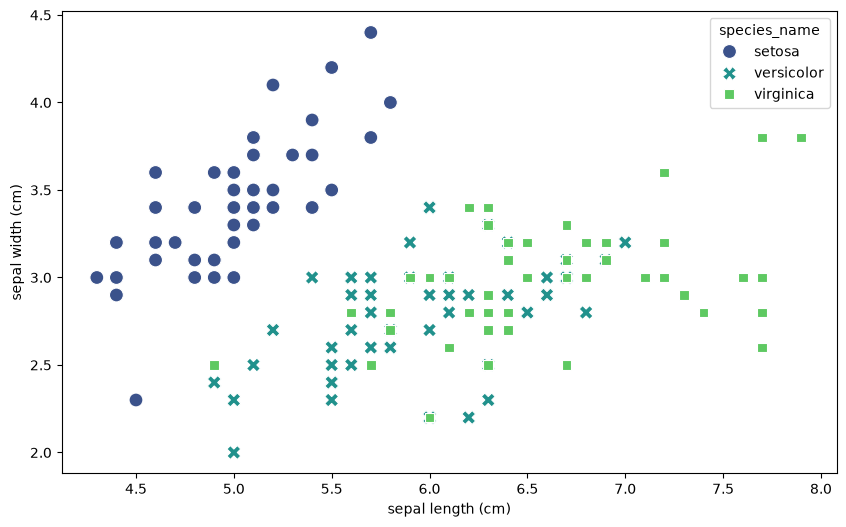

In [9]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
  data = iris_df,
  x = 'sepal length (cm)',
  y = 'sepal width (cm)',
  hue = 'species_name',
  palette = 'viridis',
  style ='species_name',
  s = 100
)

<Axes: xlabel='petal length (cm)', ylabel='petal width (cm)'>

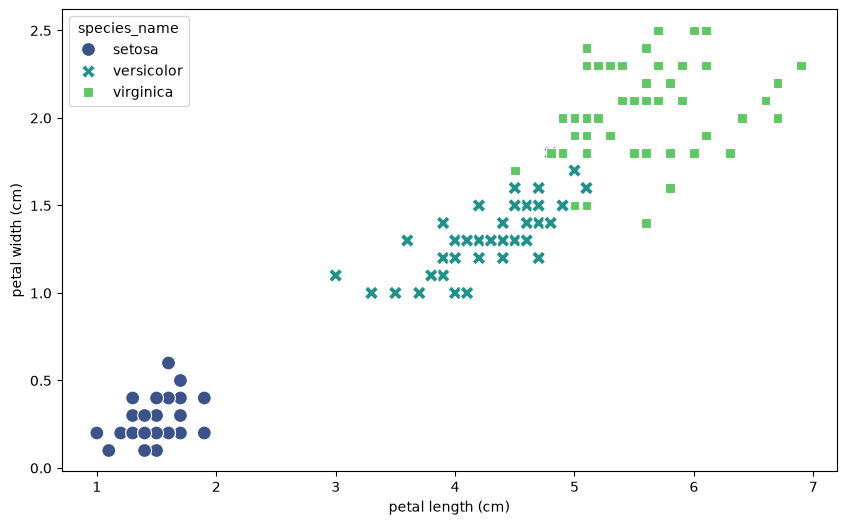

In [10]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
  data = iris_df,
  x = 'petal length (cm)',
  y = 'petal width (cm)',
  hue = 'species_name',
  palette = 'viridis',
  style ='species_name',
  s = 100
)

In [12]:
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 120 samples
Test set size: 30 samples


In [ ]:
model = LogisticRegression(max_iter=200)

model.fit(X_train, y_train)
print("Model training completed.")

Model training completed.


In [16]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the model: {accuracy:.2f}")

Accuracy of the model: 1.00


In [18]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

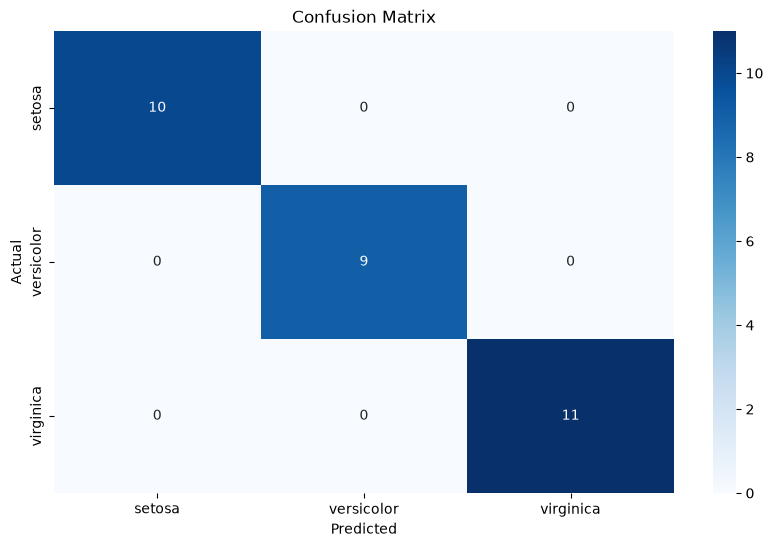

In [20]:
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [22]:
print(classification_report(y_test, y_pred, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



#### Making Predictions for new Data 

In [ ]:
new_flower = [[5.1, 3.5, 1.4, 0.2]]

In [25]:
new_flower

[[5.1, 3.5, 1.4, 0.2]]

In [26]:
predicted_class = model.predict(new_flower)

predicted_species = iris.target_names[predicted_class][0]
print(f"The predicted species for the new flower is: {predicted_species}")

The predicted species for the new flower is: setosa


---